# Model Building & Evaluation
**Goal**: The goal is to predict an outcome based on the data here selected.

---

In [1]:
%load_ext autoreload
%autoreload 2

# Now import your function
from functions import read_file, features_target_extract
#import libraries, functions, etc
from functions import read_file

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import yaml

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor,AdaBoostRegressor, GradientBoostingRegressor

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, make_scorer

from sklearn.model_selection import cross_val_score

import optuna
import optuna.visualization as vis
import time

import scipy.stats as st

## 1. Load Clean Data & Define X / y

In [2]:
yaml_path = "../config.yaml"
inp_data_section = 'output_data'
file_name = 'file1'

X = read_file(yaml_path, inp_data_section, file_name)
X.head(2)

,job_title,company_size,company_region,work_year,salary_in_usd
0,Machine Learning Engineer,M,North_America,2024,200200
1,Machine Learning Engineer,M,North_America,2024,186915


## 2. Train / Test Split

In [3]:
X, features, target = features_target_extract(X, [], 'salary_in_usd')
display(X.head(2))
display(features.head(2))
display(target)

,job_title,company_size,company_region,work_year,salary_in_usd
0,Machine Learning Engineer,M,North_America,2024,200200
1,Machine Learning Engineer,M,North_America,2024,186915


,job_title,company_size,company_region,work_year
0,Machine Learning Engineer,M,North_America,2024
1,Machine Learning Engineer,M,North_America,2024


0        200200
1        186915
2        240240
3        221596
4        240240
          ...  
29557    412000
29558    151000
29559    105000
29560    100000
29561     94665
Name: salary_in_usd, Length: 29562, dtype: int64

In [4]:
#Now Train - Split:
X_train,X_test, y_train,y_test = train_test_split(features,target,test_size=0.2, random_state=0)
display(X_train.head(2))
display(X_test.head(2))

,job_title,company_size,company_region,work_year
5725,Data Engineer,M,North_America,2024
11242,Data Engineer,M,North_America,2024


,job_title,company_size,company_region,work_year
11279,Machine Learning Engineer,M,North_America,2024
28845,Data Analyst,M,Europe_West,2022


In [5]:
from functions import dummies_catcols, df_full_standarized
#Creating dataset with dummies for categorical columns
nonnum_cols = ['job_title','company_size','company_region']
X_train_trans_df, X_test_trans_df = dummies_catcols(X_train,X_test,nonnum_cols)

#separating numerical columns dataset
num_cols= ['work_year'] # which columns are treated as numerical from the data set for the model
X_train_num = X_train[num_cols]  
X_test_num = X_test[num_cols]  
#creating a full data set of all the columns (categorical + numerical) standarized.

X_train_std_df, X_test_std_df = df_full_standarized(X_train_trans_df,X_test_trans_df,X_train_num,X_test_num)

## 3. Model - Linear Regression


### 3.1 Base model -Linear Regression

In [13]:
from functions import linear_regmodelling, RanForeRegr_modelling


In [14]:
y_pred_lr= linear_regmodelling(X_train_std_df, X_test_std_df, y_train, y_test)

MAE  46410.64
RMSE,  3793760498.42
R2 score,  0.24


### 3.1 Base model - Random Forests

In [15]:
y_pred_rf = RanForeRegr_modelling(X_train_std_df, X_test_std_df, y_train, y_test)

  R2 Score: 0.2407
  MAE:      46253.68
  MSE:      3792608232.38
  RMSE:     61584.16


### 3.2 Optuna optimisation -Linear Regression

In [11]:
def objective(trial, confidence_level, folds):
    max_depth = trial.suggest_int("max_depth", 10, 50)
    min_samples_split = trial.suggest_int("min_samples_split", 4, 16)
    max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 250, 1000)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])

    dt = RandomForestRegressor(random_state=42,
                                max_depth=max_depth,
                                min_samples_split=min_samples_split,
                                max_leaf_nodes=max_leaf_nodes,
                                max_features=max_features)

    scores = cross_val_score(dt, X_train_std_df, y_train, cv=folds)
    mean_score = np.mean(scores)
    sem = np.std(scores, ddof=1) / np.sqrt(folds)
    tc = st.t.ppf(1-((1-confidence_level)/2), df=folds-1)
    lower_bound = mean_score - (tc * sem)
    upper_bound = mean_score + (tc * sem)

    trial.set_user_attr("CV_score_summary", [round(lower_bound,4), round(mean_score,4), round(upper_bound,4)])
    return mean_score

In [12]:
confidence_level = 0.95
folds = 10

start_time = time.time()
study = optuna.create_study(direction="maximize") # We want to have the maximum values for the R2 scores
study.optimize(lambda trial: objective(trial, confidence_level, folds), n_trials=45)
#study.optimize(objective(**settings), n_trials=45) # n_trials is the number of combinations of hyperparameters to test.
end_time = time.time()

print("\n")
print(f"Time taken to find the best combination of hyperparameters among the given ones: {end_time - start_time: .4f} seconds")
print("\n")
print("The best combination of hyperparameters found was: ", study.best_params)
print(f"The best R2 found was: {study.best_value: .4f}")

[I 2026-06-18 17:17:29,535] A new study created in memory with name: no-name-6b564845-d7ab-45c3-a9d0-8930c662bb3d
[I 2026-06-18 17:17:33,002] Trial 0 finished with value: 0.21859035218340503 and parameters: {'max_depth': 28, 'min_samples_split': 7, 'max_leaf_nodes': 815, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.21859035218340503.
[I 2026-06-18 17:17:36,265] Trial 1 finished with value: 0.21953220187939645 and parameters: {'max_depth': 45, 'min_samples_split': 14, 'max_leaf_nodes': 600, 'max_features': 'log2'}. Best is trial 1 with value: 0.21953220187939645.
[I 2026-06-18 17:17:38,934] Trial 2 finished with value: 0.21614069247167586 and parameters: {'max_depth': 13, 'min_samples_split': 12, 'max_leaf_nodes': 308, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.21953220187939645.
[I 2026-06-18 17:17:42,406] Trial 3 finished with value: 0.2183774024468838 and parameters: {'max_depth': 24, 'min_samples_split': 6, 'max_leaf_nodes': 584, 'max_features': 'sqrt'}. Best i



Time taken to find the best combination of hyperparameters among the given ones:  150.9294 seconds


The best combination of hyperparameters found was:  {'max_depth': 22, 'min_samples_split': 16, 'max_leaf_nodes': 686, 'max_features': 'log2'}
The best R2 found was:  0.2198


Compared to the base line both R2 are different, baseline R2 (0.2407)> optuna R2 (0.2198) as each one was computed with different procedure, same underlying model family, roughly similar hyperparameters. It does not indicate a real performance drop.
To actually verify this is the explanation rather than something else, we run the baseline hyperparameters through the same CV procedure Optuna used.

In [16]:
PARAMS_baseline = {
    'n_estimators': 100,
    'max_depth': 20,
    'random_state': 42
}

rf_baseline = RandomForestRegressor(**PARAMS_baseline)

scores_baseline = cross_val_score(rf_baseline, X_train_std_df, y_train, cv=folds)

print(f"Baseline params under CV — per-fold R2: {scores_baseline}")
print(f"Baseline params under CV — mean R2: {np.mean(scores_baseline):.4f}")

Baseline params under CV — per-fold R2: [0.2132293  0.22782917 0.23776059 0.19969017 0.19721902 0.22669352
 0.22968463 0.24724043 0.18980548 0.20139991]
Baseline params under CV — mean R2: 0.2171


So yes: confirmed, the procedure (CV averaging vs single lucky split) explains the apparent "drop," not the hyperparameters. Optuna's combination is marginally better than baseline under the same fair comparison, not worse.

## 4. TBD

In [17]:
# #study.trials[-1].user_attrs
results = sorted([(index,
  trial.user_attrs['CV_score_summary'][0],
  trial.user_attrs['CV_score_summary'][1],
  trial.user_attrs['CV_score_summary'][2]) for index, trial in enumerate(study.trials)], key=lambda x: x[2], reverse=True)

print(f"The R2 confidence interval for the best combination of hyperparameters is: {results[0][1:]}")
#len(study.trials)

The R2 confidence interval for the best combination of hyperparameters is: (np.float64(0.2064), np.float64(0.2198), np.float64(0.2331))


## 5. TBD

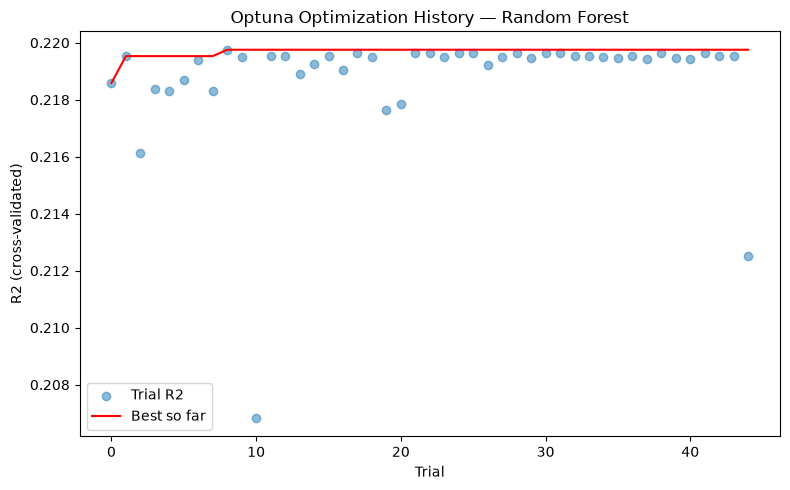

In [19]:
# Plot optimization history
trials_df = study.trials_dataframe()

best_so_far = trials_df['value'].cummax()  # cummax since you're maximizing R2

plt.figure(figsize=(8, 5))
plt.scatter(trials_df['number'], trials_df['value'], alpha=0.5, label='Trial R2')
plt.plot(trials_df['number'], best_so_far, color='red', label='Best so far')
plt.xlabel('Trial')
plt.ylabel('R2 (cross-validated)')
plt.title('Optuna Optimization History — Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

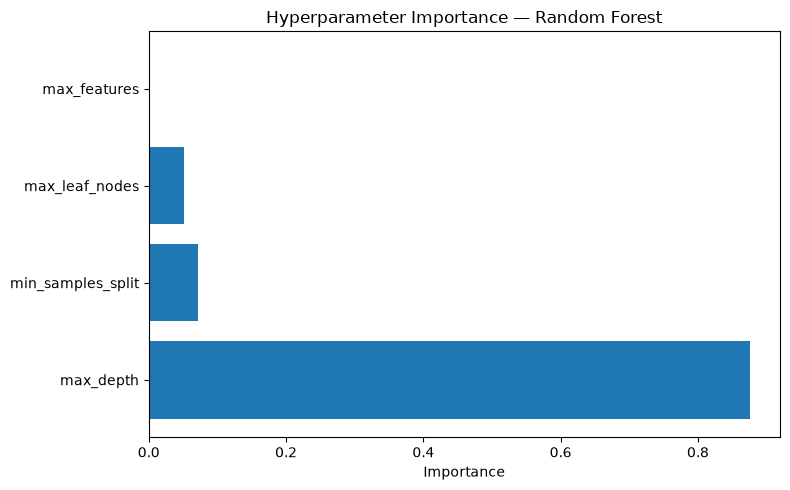

In [20]:
import optuna.importance

importances = optuna.importance.get_param_importances(study)

plt.figure(figsize=(8, 5))
plt.barh(list(importances.keys()), list(importances.values()))
plt.xlabel('Importance')
plt.title('Hyperparameter Importance — Random Forest')
plt.tight_layout()
plt.show()

## 6. Evaluating on Test set

Let's evaluate this model on the TEST set (the models were evaluated with the samples in the train set).

In [22]:
best_model = RandomForestRegressor(random_state=42, **study.best_params)
best_model.fit(X_train_std_df, y_train)
y_pred_test_df = best_model.predict(X_test_std_df)

print(f"Test MAE: {mean_absolute_error(y_pred_test_df, y_test): .3f}")
print(f"Test MSE: {mean_squared_error(y_pred_test_df, y_test): .3f}")
print(f"Test RMSE: {root_mean_squared_error(y_pred_test_df, y_test): .3f}")
print(f"Test R2 score:  {best_model.score(X_test_std_df, y_test): .3f}")

Test MAE:  46137.269
Test MSE:  3765245711.715
Test RMSE:  61361.598
Test R2 score:   0.246


## 7. Final Model Evaluation
> Now, after having optimised, we ompare all models

In [ ]:
#TBD
y_pred_lr= linear_regmodelling(X_train_std_df, X_test_std_df, y_train, y_test) # Base model linear regression
y_pred_rf = RanForeRegr_modelling(X_train_std_df, X_test_std_df, y_train, y_test) # Base model Random Forest
y_pred_test_df = best_model.predict(X_test_std_df) # Best model optimised with Optuna on Random Forest

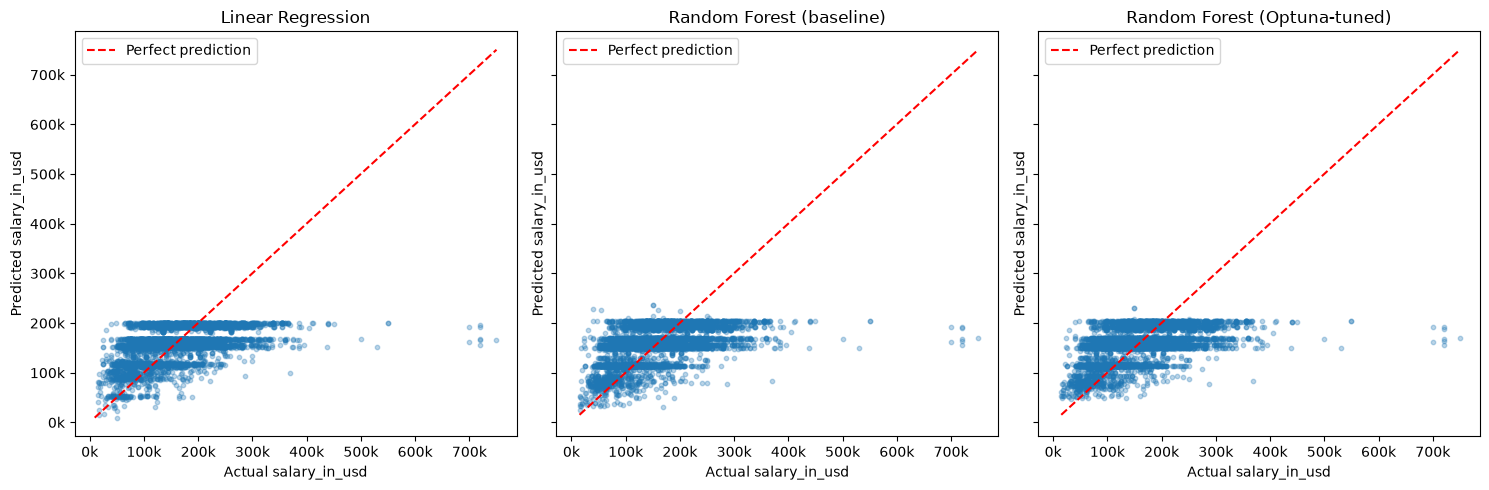

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

preds = {
    'Linear Regression': y_pred_lr,
    'Random Forest (baseline)': y_pred_rf,
    'Random Forest (Optuna-tuned)': y_pred_test_df
}

def thousands_formatter(x, pos):
    return f'{x/1000:.0f}k'

for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_test, y_pred, alpha=0.3, s=10)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, color='red', linestyle='--', label='Perfect prediction')
    ax.set_xlabel('Actual salary_in_usd')
    ax.set_ylabel('Predicted salary_in_usd')
    ax.set_title(name)
    ax.legend()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(thousands_formatter))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(thousands_formatter))

plt.tight_layout()
plt.show()

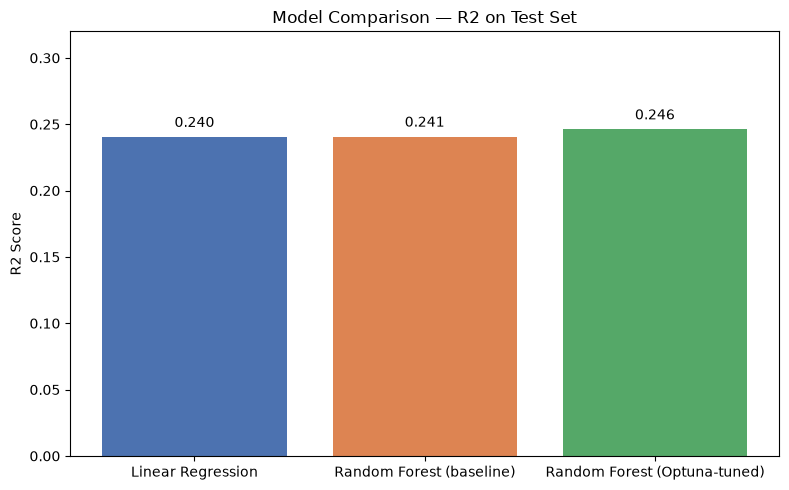

In [24]:
model_names = ['Linear Regression', 'Random Forest (baseline)', 'Random Forest (Optuna-tuned)']
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_test_df)
]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, r2_scores, color=['#4C72B0', '#DD8452', '#55A868'])
plt.ylabel('R2 Score')
plt.title('Model Comparison — R2 on Test Set')
plt.ylim(0, max(r2_scores) * 1.3)

for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
              f'{score:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 9. Conclusions

Across all four model families tested — KNN, Linear Regression, Random Forest, and Bagging-RF — test performance converged to a narrow R² range of roughly 0.20 to 0.24, depending on evaluation method (single train/test split vs. cross-validation). 
Bayesian hyperparameter tuning on Random Forest, validated under 10-fold cross-validation, produced a mean R² of 0.22.
This convergence across structurally different algorithms suggests the limiting factor is not model choice or hyperparameter tuning, but the information content of the available features. 
A likely next step is incorporating experience_level, identified earlier as a strong salary predictor but currently outside this feature set.